# Kubernetes Namespace Resource Usage Analysis

This notebook queries Prometheus for CPU and Memory usage by namespace and creates bar charts for visualization.

**Target Namespaces:** `smo`, `ricxapp`, `ricrapp`, `ricplt`, `nonrtric`, `e2sim`

In [38]:
# Import libraries
import requests
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from datetime import datetime

# Enable inline plotting
%matplotlib inline

In [39]:
# Configuration
PROMETHEUS_URL = "http://kube-prometheus-stack-prometheus.monitoring.svc.cluster.local:9090"
NAMESPACES = ["smo", "ricxapp", "ricrapp", "ricplt", "nonrtric", "e2sim"]

# Time Interval Configuration
# Set START_TIME and END_TIME to specific timestamps (YYYY-MM-DD HH:MM:SS)
# Leave as None to analyze the last hour relative to now
START_TIME = "2026-01-09 22:00:00"  # e.g., "2026-01-02 14:00:00"
END_TIME = "2026-01-12 23:00:00"    # e.g., "2026-01-02 14:30:00"

# Logic to determine query parameters
eval_time = None
duration = "1h"  # Default to last hour

if START_TIME and END_TIME:
    fmt = "%Y-%m-%d %H:%M:%S"
    try:
        t_start = datetime.strptime(START_TIME, fmt)
        t_end = datetime.strptime(END_TIME, fmt)
        
        # Calculate duration in minutes
        diff_minutes = int((t_end - t_start).total_seconds() / 60)
        if diff_minutes <= 0:
            raise ValueError("END_TIME must be after START_TIME")
            
        duration = f"{diff_minutes}m"
        eval_time = t_end.timestamp()
        time_label = f"{START_TIME} to {END_TIME}"
    except ValueError as e:
        print(f"Error parsing dates: {e}. Falling back to default.")
        time_label = f"Last {duration}"
else:
    time_label = f"Last {duration}"

print(f"Prometheus URL: {PROMETHEUS_URL}")
print(f"Target Namespaces: {NAMESPACES}")
print(f"Analysis Interval: {time_label} (Duration: {duration})")

Prometheus URL: http://kube-prometheus-stack-prometheus.monitoring.svc.cluster.local:9090
Target Namespaces: ['smo', 'ricxapp', 'ricrapp', 'ricplt', 'nonrtric', 'e2sim']
Analysis Interval: 2026-01-09 22:00:00 to 2026-01-12 23:00:00 (Duration: 4380m)


In [40]:
# Helper functions
def query_prometheus(query, time=None):
    """Execute a PromQL query and return the result."""
    try:
        params = {"query": query}
        if time:
            params["time"] = time
            
        response = requests.get(
            f"{PROMETHEUS_URL}/api/v1/query",
            params=params,
            timeout=30
        )
        response.raise_for_status()
        data = response.json()
        if data["status"] == "success":
            return data["data"]["result"]
        else:
            print(f"Query failed: {data.get('error', 'Unknown error')}")
            return []
    except requests.exceptions.RequestException as e:
        print(f"Error querying Prometheus: {e}")
        return []

def parse_results(results, namespaces):
    """Parse Prometheus results into a dict keyed by namespace."""
    data = {ns: 0.0 for ns in namespaces}
    for result in results:
        ns = result["metric"].get("namespace", "")
        if ns in namespaces:
            data[ns] = float(result["value"][1])
    return data

def bytes_to_mib(value):
    """Convert bytes to MiB."""
    return value / (1024 * 1024)

print("Helper functions defined ✓")

Helper functions defined ✓


## Query Prometheus for Resource Metrics (Mean & Std Dev)
We calculate the average and standard deviation over the configured time window.

In [41]:
# Query CPU usage (cores) per namespace
# We use subqueries to calculate avg and stddev over the time window
# Syntax: query[range:resolution]

# Main query for namespaces
def get_cpu_query(agg_func):
    return f'''
    {agg_func}_over_time(
        sum by (namespace) (
            rate(container_cpu_usage_seconds_total{{
                namespace=~"smo|ricxapp|ricrapp|ricplt|nonrtric",
                container!="",
                container!="POD"
            }}[5m])
        )[{duration}:1m]
    )
    '''

# Specific query for e2sim pod within ricxapp namespace
def get_e2sim_cpu_query(agg_func):
    return f'''
    {agg_func}_over_time(
        sum(
            rate(container_cpu_usage_seconds_total{{
                namespace="ricxapp",
                pod=~"e2sim.*",
                container!="",
                container!="POD"
            }}[5m])
        )[{duration}:1m]
    )
    '''

# Execute queries for Mean
cpu_mean_raw = query_prometheus(get_cpu_query("avg"), time=eval_time)
cpu_mean = parse_results(cpu_mean_raw, NAMESPACES)

e2sim_mean_raw = query_prometheus(get_e2sim_cpu_query("avg"), time=eval_time)
if e2sim_mean_raw:
    val = float(e2sim_mean_raw[0]['value'][1])
    cpu_mean['e2sim'] = val
    if 'ricxapp' in cpu_mean:
        cpu_mean['ricxapp'] = max(0, cpu_mean['ricxapp'] - val)

# Execute queries for StdDev
cpu_std_raw = query_prometheus(get_cpu_query("stddev"), time=eval_time)
cpu_std = parse_results(cpu_std_raw, NAMESPACES)

e2sim_std_raw = query_prometheus(get_e2sim_cpu_query("stddev"), time=eval_time)
if e2sim_std_raw:
    val = float(e2sim_std_raw[0]['value'][1])
    cpu_std['e2sim'] = val
    # Estimate stddev for ricxapp (excluding e2sim)
    # Assuming independence: Var(Rest) = Var(Total) - Var(E2Sim)
    if 'ricxapp' in cpu_std:
        var_total = cpu_std['ricxapp']**2
        var_e2sim = val**2
        cpu_std['ricxapp'] = np.sqrt(max(0, var_total - var_e2sim))

print(f"CPU Usage (cores) over {time_label}:")
for ns in NAMESPACES:
    m = cpu_mean.get(ns, 0) * 1000
    s = cpu_std.get(ns, 0) * 1000
    print(f"  {ns}: {m:.1f}m ± {s:.1f}m")

CPU Usage (cores) over 2026-01-09 22:00:00 to 2026-01-12 23:00:00:
  smo: 25.3m ± 2.1m
  ricxapp: 0.4m ± 0.0m
  ricrapp: 1.5m ± 0.3m
  ricplt: 37.1m ± 4.6m
  nonrtric: 76.4m ± 3.4m
  e2sim: 0.2m ± 0.0m


In [42]:
# Query Memory usage (bytes) per namespace
def get_mem_query(agg_func):
    return f'''
    {agg_func}_over_time(
        sum by (namespace) (
            container_memory_working_set_bytes{{
                namespace=~"smo|ricxapp|ricrapp|ricplt|nonrtric",
                container!="",
                container!="POD"
            }}
        )[{duration}:1m]
    )
    '''

def get_e2sim_mem_query(agg_func):
    return f'''
    {agg_func}_over_time(
        sum(
            container_memory_working_set_bytes{{
                namespace="ricxapp",
                pod=~"e2sim.*",
                container!="",
                container!="POD"
            }}
        )[{duration}:1m]
    )
    '''

# Execute queries for Mean
mem_mean_raw = query_prometheus(get_mem_query("avg"), time=eval_time)
mem_mean = parse_results(mem_mean_raw, NAMESPACES)

e2sim_mem_mean = query_prometheus(get_e2sim_mem_query("avg"), time=eval_time)
if e2sim_mem_mean:
    val = float(e2sim_mem_mean[0]['value'][1])
    mem_mean['e2sim'] = val
    if 'ricxapp' in mem_mean:
        mem_mean['ricxapp'] = max(0, mem_mean['ricxapp'] - val)

# Execute queries for StdDev
mem_std_raw = query_prometheus(get_mem_query("stddev"), time=eval_time)
mem_std = parse_results(mem_std_raw, NAMESPACES)

e2sim_mem_std = query_prometheus(get_e2sim_mem_query("stddev"), time=eval_time)
if e2sim_mem_std:
    val = float(e2sim_mem_std[0]['value'][1])
    mem_std['e2sim'] = val
    # Estimate stddev for ricxapp (excluding e2sim)
    if 'ricxapp' in mem_std:
        var_total = mem_std['ricxapp']**2
        var_e2sim = val**2
        mem_std['ricxapp'] = np.sqrt(max(0, var_total - var_e2sim))

print(f"Memory Usage over {time_label}:")
for ns in NAMESPACES:
    m = bytes_to_mib(mem_mean.get(ns, 0))
    s = bytes_to_mib(mem_std.get(ns, 0))
    print(f"  {ns}: {m:.1f} MiB ± {s:.1f} MiB")

Memory Usage over 2026-01-09 22:00:00 to 2026-01-12 23:00:00:
  smo: 195.4 MiB ± 7.8 MiB
  ricxapp: 8.6 MiB ± 0.1 MiB
  ricrapp: 39.8 MiB ± 0.8 MiB
  ricplt: 1112.5 MiB ± 4.4 MiB
  nonrtric: 7113.8 MiB ± 130.6 MiB
  e2sim: 1.7 MiB ± 0.0 MiB


## Resource Usage Summary Table (Mean ± Std Dev)

In [43]:
# Create summary table
print("=" * 80)
print(f"RESOURCE USAGE SUMMARY ({time_label})")
print("=" * 80)
print(f"{'Namespace':<15} {'CPU Usage (Mean ± Std)':<30} {'Memory Usage (Mean ± Std)':<30}")
print("-" * 80)

for ns in NAMESPACES:
    cpu_m = cpu_mean.get(ns, 0) * 1000  # millicores
    cpu_s = cpu_std.get(ns, 0) * 1000
    mem_m = bytes_to_mib(mem_mean.get(ns, 0))
    mem_s = bytes_to_mib(mem_std.get(ns, 0))
    
    print(f"{ns:<15} {cpu_m:>6.1f} ± {cpu_s:<6.1f} m        {mem_m:>6.1f} ± {mem_s:<6.1f} MiB")

print("-" * 80)
# Totals (approximate for std dev, assuming independence)
total_cpu_m = sum(cpu_mean.get(ns, 0) for ns in NAMESPACES) * 1000
total_cpu_s = np.sqrt(sum((cpu_std.get(ns, 0) * 1000)**2 for ns in NAMESPACES))

total_mem_m = bytes_to_mib(sum(mem_mean.get(ns, 0) for ns in NAMESPACES))
total_mem_s = np.sqrt(sum(bytes_to_mib(mem_std.get(ns, 0))**2 for ns in NAMESPACES))

print(f"{'TOTAL':<15} {total_cpu_m:>6.1f} ± {total_cpu_s:<6.1f} m        {total_mem_m:>6.1f} ± {total_mem_s:<6.1f} MiB")
print("=" * 80)

RESOURCE USAGE SUMMARY (2026-01-09 22:00:00 to 2026-01-12 23:00:00)
Namespace       CPU Usage (Mean ± Std)         Memory Usage (Mean ± Std)     
--------------------------------------------------------------------------------
smo               25.3 ± 2.1    m         195.4 ± 7.8    MiB
ricxapp            0.4 ± 0.0    m           8.6 ± 0.1    MiB
ricrapp            1.5 ± 0.3    m          39.8 ± 0.8    MiB
ricplt            37.1 ± 4.6    m        1112.5 ± 4.4    MiB
nonrtric          76.4 ± 3.4    m        7113.8 ± 130.6  MiB
e2sim              0.2 ± 0.0    m           1.7 ± 0.0    MiB
--------------------------------------------------------------------------------
TOTAL            140.9 ± 6.1    m        8471.8 ± 130.9  MiB


## CPU and Memory Bar Charts

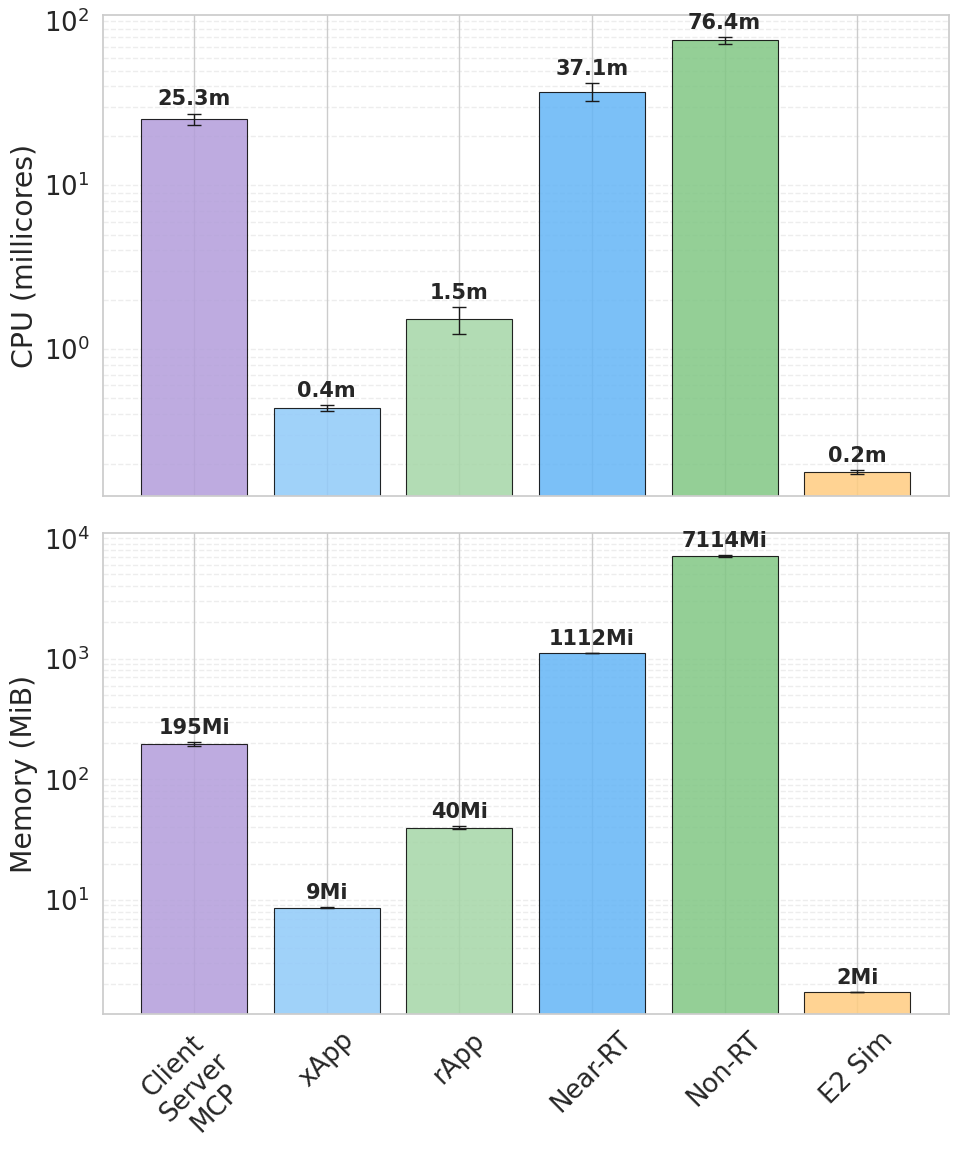


✓ Chart saved to: namespace_usage_notebook.png


In [44]:
# Create bar charts
sns.set_theme(style='whitegrid', font_scale=1.7)

# Stacked vertically (2 rows, 1 column), sharing X axis
fig, axes = plt.subplots(2, 1, figsize=(10, 12), sharex=True)

# Define colors based on architecture diagram
# smo: Purple, ricxapp: Blue, ricrapp: Green, ricplt: Blue, nonrtric: Green, e2sim: Orange
# Using hex codes approximating the diagram colors
colors = ['#B39DDB', '#90CAF9', '#A5D6A7', '#64B5F6', '#81C784', '#FFCC80']
# Map namespaces to colors if order changes, but here we rely on NAMESPACES list order:
# ["smo", "ricxapp", "ricrapp", "ricplt", "nonrtric", "e2sim"]

# Define display labels for x-axis
name_mapping = {
    "smo": "Client\nServer\nMCP",
    "ricxapp": "xApp",
    "ricrapp": "rApp",
    "ricplt": "Near-RT",
    "nonrtric": "Non-RT",
    "e2sim": "E2 Sim"
}
plot_labels = [name_mapping.get(ns, ns) for ns in NAMESPACES]

# CPU Usage Chart
ax1 = axes[0]
cpu_m_vals = [cpu_mean.get(ns, 0) * 1000 for ns in NAMESPACES]  # millicores
cpu_s_vals = [cpu_std.get(ns, 0) * 1000 for ns in NAMESPACES]

bars1 = ax1.bar(plot_labels, cpu_m_vals, yerr=cpu_s_vals, capsize=5,
                color=colors, edgecolor='black', linewidth=0.8, alpha=0.85,
                error_kw=dict(lw=1, capsize=5, capthick=1))
ax1.set_ylabel('CPU (millicores)')
ax1.set_yscale('log')
# X-axis labels are shared and shown on the bottom plot
ax1.grid(axis='y', linestyle='--', alpha=0.35, which='both')

# Add value labels
for bar, mean, std in zip(bars1, cpu_m_vals, cpu_s_vals):
    if mean > 0:
        # Mean above the error bar
        height_top = mean + std if std > 0 else mean
        ax1.annotate(f'{mean:.1f}m',
                    xy=(bar.get_x() + bar.get_width() / 2, height_top),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=15, fontweight='bold')
        
        # Std Dev inside the bar (below the top) - REMOVED

# Memory Usage Chart
ax2 = axes[1]
mem_m_vals = [bytes_to_mib(mem_mean.get(ns, 0)) for ns in NAMESPACES]
mem_s_vals = [bytes_to_mib(mem_std.get(ns, 0)) for ns in NAMESPACES]

bars2 = ax2.bar(plot_labels, mem_m_vals, yerr=mem_s_vals, capsize=5,
                color=colors, edgecolor='black', linewidth=0.8, alpha=0.85,
                error_kw=dict(lw=1, capsize=5, capthick=1))
ax2.set_ylabel('Memory (MiB)')
ax2.set_yscale('log')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', linestyle='--', alpha=0.35, which='both')

# Add value labels
for bar, mean, std in zip(bars2, mem_m_vals, mem_s_vals):
    if mean > 0:
        # Mean above the error bar
        height_top = mean + std if std > 0 else mean
        ax2.annotate(f'{mean:.0f}Mi',
                    xy=(bar.get_x() + bar.get_width() / 2, height_top),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=15, fontweight='bold')
        
plt.tight_layout()
plt.savefig('namespace_usage_notebook.png', dpi=300, bbox_inches='tight')
plt.savefig('namespace_usage_notebook.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Chart saved to: namespace_usage_notebook.png")